# MNIST as contextual bandits

# Run experiment and store results

In [ ]:
%%time
!bash run_mnist_refactor.sh

Running FLoRES agent
Results saved to output/FLoRES_eps_5_20250902.pkl
Average cumulative reward: 30471.80
Total time: 457.9995 seconds

Running LoFi agent
Results saved to output/LoFi_eps_5_20250902.pkl
Average cumulative reward: 24628.10
Total time: 220.7402 seconds

Running FLoRESLite agent


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import seaborn as sns

In [67]:
pd.set_option("display.float_format", lambda x: format(x, "0,.2f"))

In [63]:
sns.set_palette("colorblind")
%config InlineBackend.figure_format = "retina"

In [5]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]

In [187]:
def plot_rewards(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)

    stat = rewards.expanding(min_periods=1000).mean()
    median = stat.mean(axis=1)
    # lbound = stat.quantile(0.25, axis=1)
    # ubound = stat.quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.2, color=color, hatch=hatch)

In [128]:
def plot_rewards(rewards, hatch, color, **kwargs):
    rewards = pd.DataFrame(rewards)
    rewards_oracle = np.ones(len(rewards))[:, None]
    regret = rewards_oracle - rewards

    regret = regret.cumsum()
    median = regret.mean(axis=1)
    # lbound = stat.quantile(0.25, axis=1)
    # ubound = stat.quantile(0.75, axis=1)
    
    median.plot(color=color, **kwargs)
    # plt.fill_between(median.index, lbound, ubound, alpha=0.2, color=color, hatch=hatch)

In [189]:
date = "20250902"

In [190]:
agents = ["LRKF", "FLoRES", "FLoRESLite", "adamw", "LoFi", "muon"]

In [191]:
ls output/*20250902*

output/FLoRESLite_eps_5_20250902.pkl
output/FLoRESLite_predictive_bayes_20250902.pkl
output/FLoRES_eps_5_20250902.pkl
output/FLoRES_predictive_bayes_20250902.pkl
output/LRKF_eps_5_20250902.pkl
output/LRKF_predictive_bayes_20250902.pkl
output/LoFi_eps_5_20250902.pkl
output/LoFi_predictive_bayes_20250902.pkl
output/LoFi_ts_20250902.pkl
output/adamw_eps_5_20250902.pkl
output/adamw_predictive_bayes_20250902.pkl
output/adamw_ts_20250902.pkl
output/muon_eps_5_20250902.pkl
output/muon_predictive_bayes_20250902.pkl
output/muon_ts_20250902.pkl


In [192]:
agent_map = {agent: agent for agent in agents}
agent_map["FLoRES"] = "HiLoFi"
agent_map["FLoRESLite"] = "LoLoFi"

CPU times: user 275 ms, sys: 4.69 ms, total: 280 ms
Wall time: 279 ms


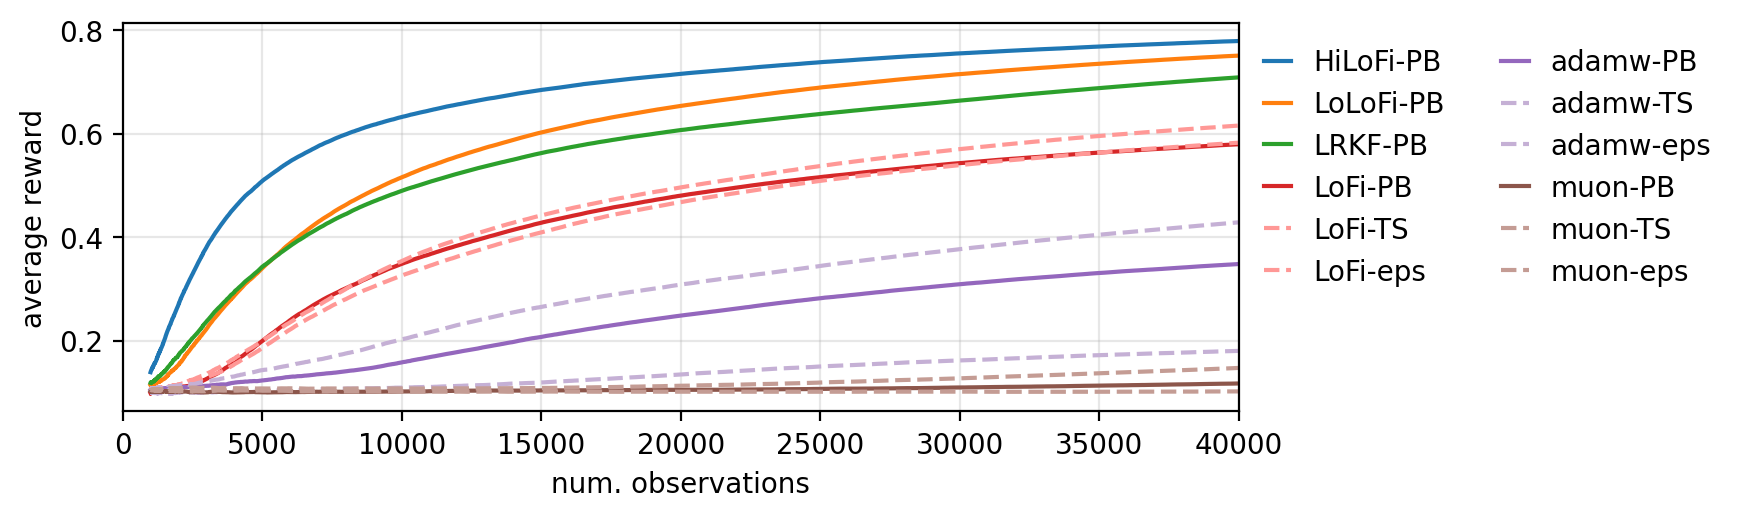

In [195]:
%%time
fig, ax = plt.subplots(figsize=(7.2, 4.2 * 0.6))

res_methods = {}

colors = sns.color_palette("tab20")
hatches = ["x", "o"]
for i, agent in enumerate(sorted(agents)):
    agent_path_predictive = f"./output/{agent}_predictive_bayes_{date}.pkl"
    agent_path_ts = f"./output/{agent}_ts_{date}.pkl"
    agent_path_eps = f"./output/{agent}_eps_5_{date}.pkl"

    agent = agent_map[agent]
    res = pd.read_pickle(agent_path_predictive)
    plot_rewards(
        res["rewards"].T, label=rf"{agent}-PB",
        color=colors[2 * i], hatch=hatches[i % 2]
    )

    res_methods[f"{agent}-pBayes"] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "PS",
        "agent": agent,
    }

    if agent in ["HiLoFi", "LoLoFi", "LRKF"]:
        continue

    res = pd.read_pickle(agent_path_ts)
    plot_rewards(
        res["rewards"].T, label=f"{agent}-TS", linestyle="--",
        color=colors[2 * i  + 1], hatch=hatches[(2 * i  + 1) % 2]
    )

    res_methods[f"{agent}-ts"] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "TS",
        "agent": agent,
    }


    res = pd.read_pickle(agent_path_eps)
    plot_rewards(
        res["rewards"].T, label=f"{agent}-eps", linestyle="--",
        color=colors[2 * i  + 1], hatch=hatches[(2 * i  + 1) % 2]
    )

    res_methods[f"{agent}-eps"] = {
        "reward": res["rewards"].sum(axis=1).mean(),
        "regret": (40_000 - res["rewards"].sum(axis=1)).mean(),
        "time": res["time"],
        "reward_prop": (res["rewards"].sum(axis=1) / 40_000).mean(),
        "reward_prop_std": (res["rewards"].sum(axis=1) / 40_000).std(),
        "sampling": "eps",
        "agent": agent,
    }



    
plt.legend(ncol=2, handlelength=1, bbox_to_anchor=(1,1), frameon=False)
plt.xlabel("num. observations")
plt.ylabel("average reward")
plt.grid(alpha=0.3)
plt.xlim(0, 40_000)
# plt.savefig("../figures/mnist-bandit-reward.png", dpi=300, bbox_inches="tight")

res_methods = pd.DataFrame(res_methods)
res_methods.loc["minutes"] = res_methods.loc["time"] / 60
res_methods = res_methods.rename({
    "reward": "cumulative reward",
}).rename({
    "FLoRES-ts": "HiLoFi-pBayes"
}, axis=1)

In [182]:
res_methods

,HiLoFi-pBayes,LoLoFi-pBayes,LRKF-pBayes,LoFi-pBayes,LoFi-ts,LoFi-eps,adamw-pBayes,adamw-ts,adamw-eps,muon-pBayes,muon-ts,muon-eps
cumulative reward,"31,167.70","30,038.50","28,354.90","23,184.50","23,304.30","24,628.10","13,922.30","7,201.90","17,144.90","4,681.90","4,069.30","5,886.30"
regret,"8,832.30","9,961.50","11,645.10","16,815.50","16,695.70","15,371.90","26,077.70","32,798.10","22,855.10","35,318.10","35,930.70","34,113.70"
time,506.44,220.48,150.32,285.80,"2,334.18",220.81,81.48,"11,493.05",75.16,37.35,"11,441.91",30.55
reward_prop,0.78,0.75,0.71,0.58,0.58,0.62,0.35,0.18,0.43,0.12,0.10,0.15
reward_prop_std,0.01,0.02,0.17,0.08,0.08,0.06,0.03,0.00,0.02,0.01,0.00,0.02
sampling,PS,PS,PS,PS,TS,eps,PS,TS,eps,PS,TS,eps
agent,HiLoFi,LoLoFi,LRKF,LoFi,LoFi,LoFi,adamw,adamw,adamw,muon,muon,muon
minutes,8.44,3.67,2.51,4.76,38.90,3.68,1.36,191.55,1.25,0.62,190.70,0.51


In [183]:
table = res_methods.loc[["regret", "minutes", "sampling", "agent"]].T
table

,regret,minutes,sampling,agent
HiLoFi-pBayes,"8,832.30",8.44,PS,HiLoFi
LoLoFi-pBayes,"9,961.50",3.67,PS,LoLoFi
LRKF-pBayes,"11,645.10",2.51,PS,LRKF
LoFi-pBayes,"16,815.50",4.76,PS,LoFi
LoFi-ts,"16,695.70",38.90,TS,LoFi
LoFi-eps,"15,371.90",3.68,eps,LoFi
adamw-pBayes,"26,077.70",1.36,PS,adamw
adamw-ts,"32,798.10",191.55,TS,adamw
adamw-eps,"22,855.10",1.25,eps,adamw
muon-pBayes,"35,318.10",0.62,PS,muon


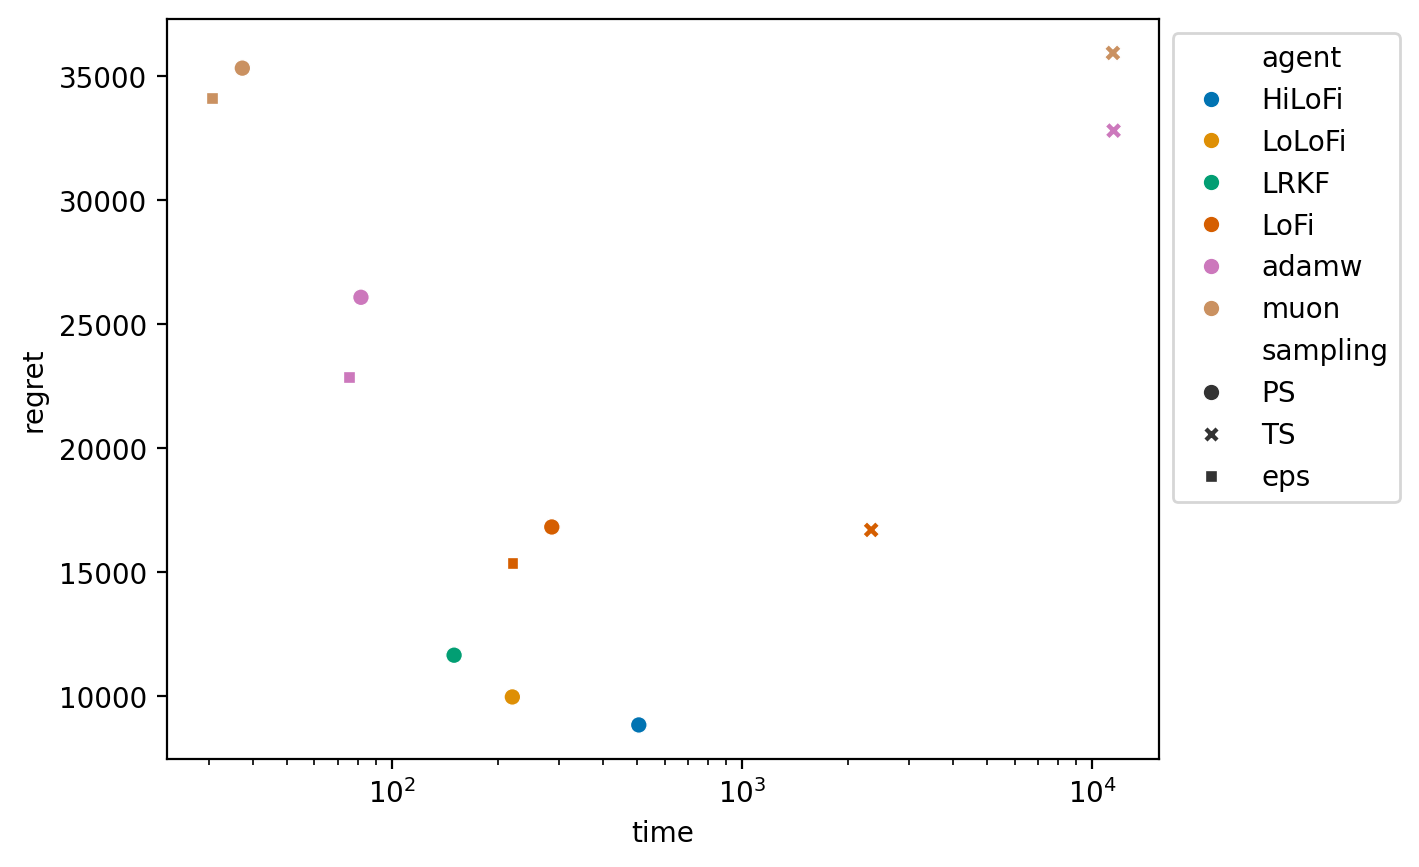

In [184]:
sns.scatterplot(
    y="regret",
    x="time",
    data=res_methods.T.reset_index(),
    hue="agent",
    style="sampling"
)
plt.xscale("log")
plt.legend(bbox_to_anchor=(1,1))

In [198]:
table = (
    res_methods.T
    .pivot_table(index="agent", columns="sampling", values=["regret", "minutes"])
)

table

minutes                regret                    
sampling      PS     TS  eps        PS        TS       eps
agent                                                     
HiLoFi      8.44    NaN  NaN  8,832.30       NaN       NaN
LRKF        2.51    NaN  NaN 11,645.10       NaN       NaN
LoFi        4.76  38.90 3.68 16,815.50 16,695.70 15,371.90
LoLoFi      3.67    NaN  NaN  9,961.50       NaN       NaN
adamw       1.36 191.55 1.25 26,077.70 32,798.10 22,855.10
muon        0.62 190.70 0.51 35,318.10 35,930.70 34,113.70

In [199]:
print(table.to_markdown())

| agent   |   ('minutes', 'PS') |   ('minutes', 'TS') |   ('minutes', 'eps') |   ('regret', 'PS') |   ('regret', 'TS') |   ('regret', 'eps') |
|:--------|--------------------:|--------------------:|---------------------:|-------------------:|-------------------:|--------------------:|
| HiLoFi  |            8.44075  |            nan      |           nan        |             8832.3 |              nan   |               nan   |
| LRKF    |            2.50533  |            nan      |           nan        |            11645.1 |              nan   |               nan   |
| LoFi    |            4.76341  |             38.9029 |             3.6802   |            16815.5 |            16695.7 |             15371.9 |
| LoLoFi  |            3.67473  |            nan      |           nan        |             9961.5 |              nan   |               nan   |
| adamw   |            1.35797  |            191.551  |             1.25266  |            26077.7 |            32798.1 |             22855.1 |

In [86]:
res_methods.T.pivot_table(index="agent", columns="sampling", values=["cumulative reward", "time"])

cumulative reward             time          
sampling                PS        TS     PS        TS
agent                                                
HiLoFi           31,167.70       NaN 506.44       NaN
LRKF             28,354.90       NaN 150.32       NaN
LoFi             23,184.50 23,304.30 285.80  2,334.18
LoLoFi           30,038.50       NaN 220.48       NaN
adamw            13,922.30  7,201.90  81.48 11,493.05
muon              4,681.90  4,069.30  37.35 11,441.91